In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold


# Đọc file
column_names = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
                'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
df = pd.read_csv('abalone.data', names=column_names)

print("Dữ liệu 5 dòng đầu tiên:")
display(df.head())

Dữ liệu 5 dòng đầu tiên:


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


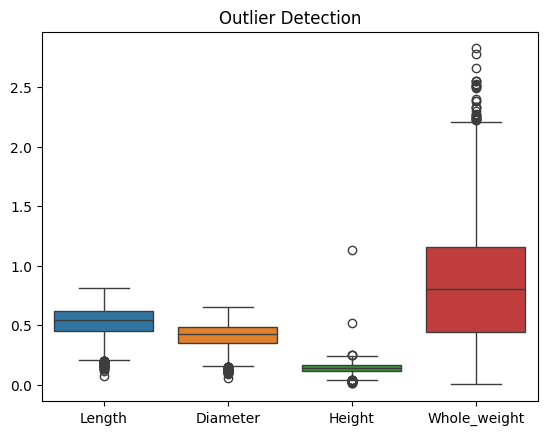

In [ ]:
# =========================
# 2. BASIC CLEANING
# =========================
df = df[df['Height'] > 0]

# Check outliers
plt.figure()
sns.boxplot(data=df[['Length','Diameter','Height','Whole_weight']])
plt.title("Outlier Detection")
plt.show()


FEATURE ENGINEERING


In [ ]:
df['Size_Area'] = df['Length'] * df['Diameter']

EDA

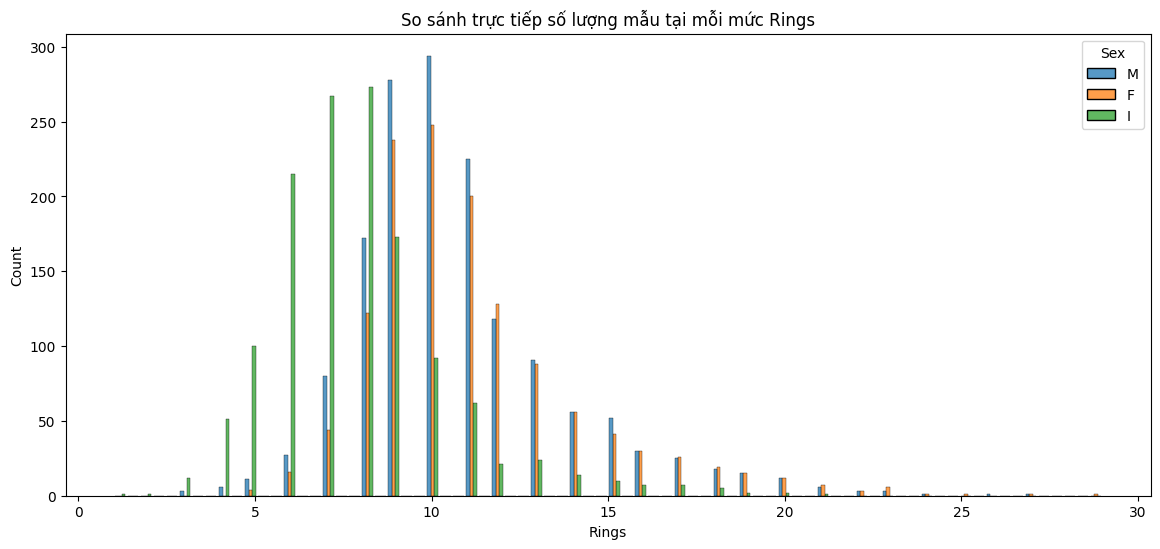

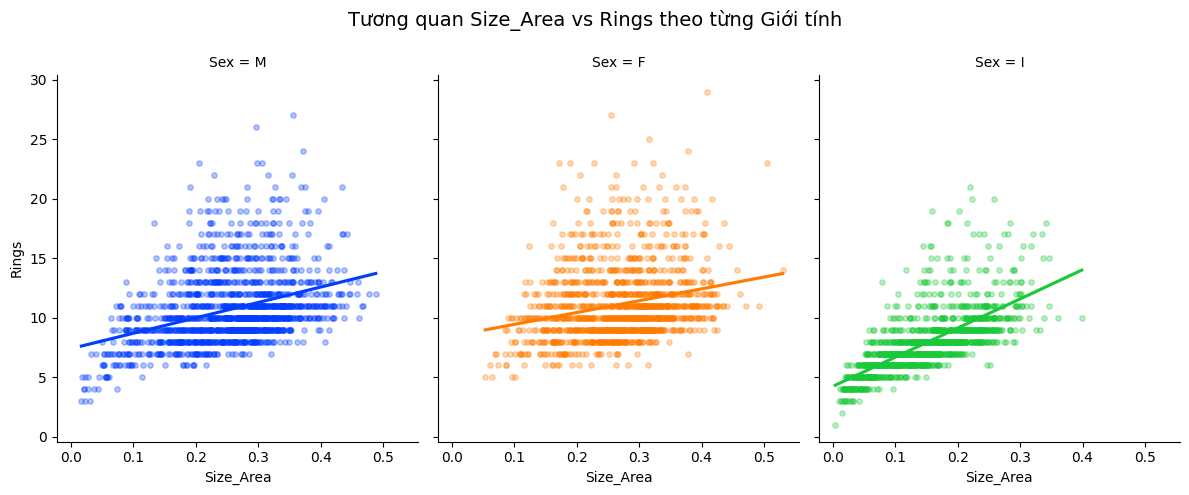

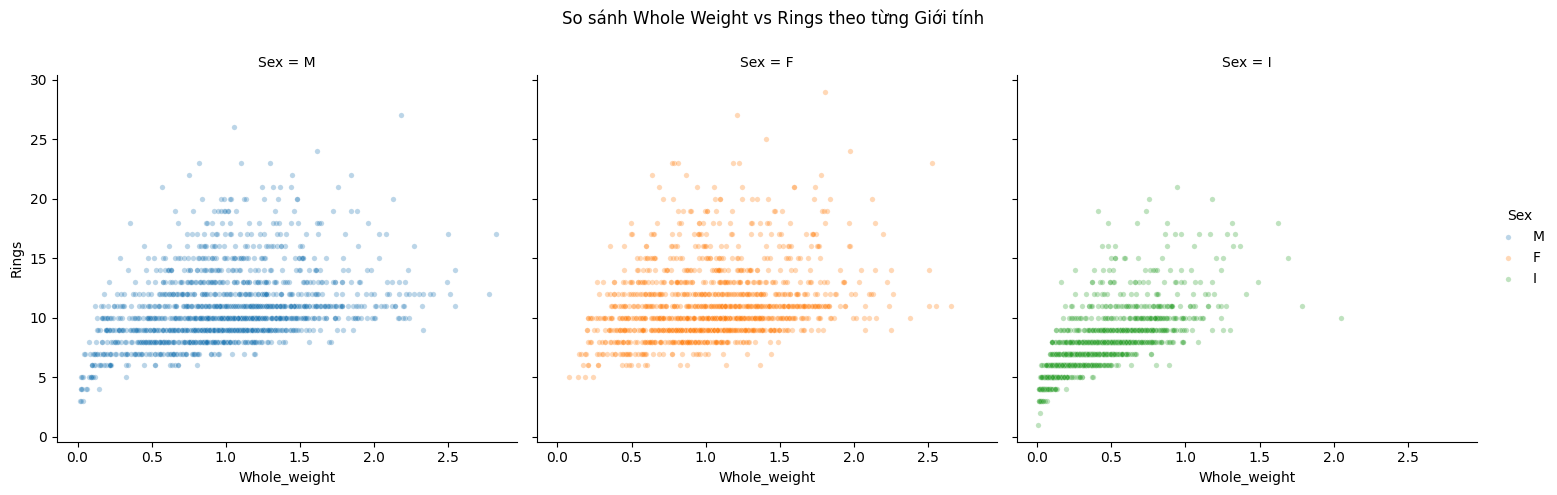

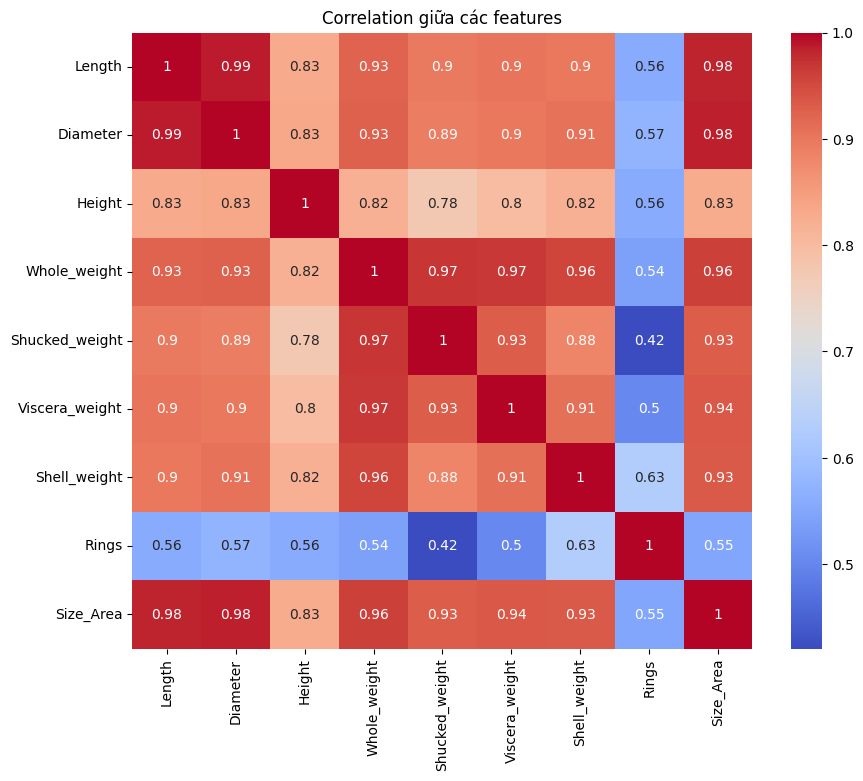

In [ ]:
# Biểu đồ phân phối Rings theo giới tính
plt.figure(figsize=(14, 6))
sns.histplot(data=df, x='Rings', hue='Sex', multiple="dodge", shrink=.8)
plt.title("So sánh trực tiếp số lượng mẫu tại mỗi mức Rings")
plt.show()

#rings-sex
#chia làm 3 cột dựa trên cột giới tính
sns.lmplot(data=df, x='Size_Area', y='Rings', col='Sex', hue='Sex',
           palette='bright', ci=None,
           scatter_kws={'alpha': 0.3, 's': 15},
           height=5, aspect=0.8)
plt.subplots_adjust(top=0.85)
plt.suptitle("Tương quan Size_Area vs Rings theo từng Giới tính", fontsize=14)
plt.show()

#rings-weight
# chia thành các cột dựa trên giới tính
g = sns.FacetGrid(df, col="Sex", hue="Sex", height=5, aspect=1)
g.map(sns.scatterplot, "Whole_weight", "Rings", alpha=0.3, s=15)
g.add_legend()
plt.subplots_adjust(top=0.85)
g.fig.suptitle('So sánh Whole Weight vs Rings theo từng Giới tính')
plt.show()

#Heatmap xem mối quan hệ
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation giữa các features")
plt.show()

In [ ]:
# =========================
# 3. TRAIN / TEST SPLIT
# =========================
X = df.drop('Rings', axis=1)
y = df['Rings'].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# =========================
# 4. SCALING
# =========================
num_cols = ['Length', 'Diameter', 'Height', 'Whole_weight',
            'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Size_Area']
cat_cols = ['Sex']

preprocessor = ColumnTransformer([
    ('num', RobustScaler(), num_cols),
    ('cat', OneHotEncoder(), cat_cols)
])

In [ ]:

# =========================
# 5. MODELS
# =========================
models = {
    "OLS Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "SVR (RBF)": SVR(kernel='rbf', C=10, epsilon=0.1)
}

results_table = []


# =========================
# 6. BASELINE
# =========================
y_mean = y_train.mean()
y_pred_test_baseline = np.full_like(y_test, y_mean)

results = []
results.append({
    "Model": "Baseline (Mean)",
    "MAE": mean_absolute_error(y_test, y_pred_test_baseline),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test_baseline)),
    "R2": r2_score(y_test, y_pred_test_baseline)
})


# =========================
# 7. CROSS VALIDATION
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    cv = cross_validate(pipe, X_train, y_train,
                        cv=kf,
                        scoring=['neg_mean_absolute_error',
                                 'neg_root_mean_squared_error',
                                 'r2'])

    results_table.append({
        "Model": name,
        "MAE": -cv['test_neg_mean_absolute_error'].mean(),
        "RMSE": -cv['test_neg_root_mean_squared_error'].mean(),
        "R2": cv['test_r2'].mean()
    })

df_res = pd.DataFrame(results_table)
print("\n--- BẢNG KẾT QUẢ ---")
print(df_res.to_string(index=False))


--- BẢNG KẾT QUẢ ---
                Model      MAE     RMSE       R2
OLS Linear Regression 1.568540 2.188030 0.527030
                Ridge 1.566470 2.188435 0.526908
            SVR (RBF) 1.454128 2.120476 0.556033


/tmp/ipykernel_343/3076124021.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=df_res, palette='magma')


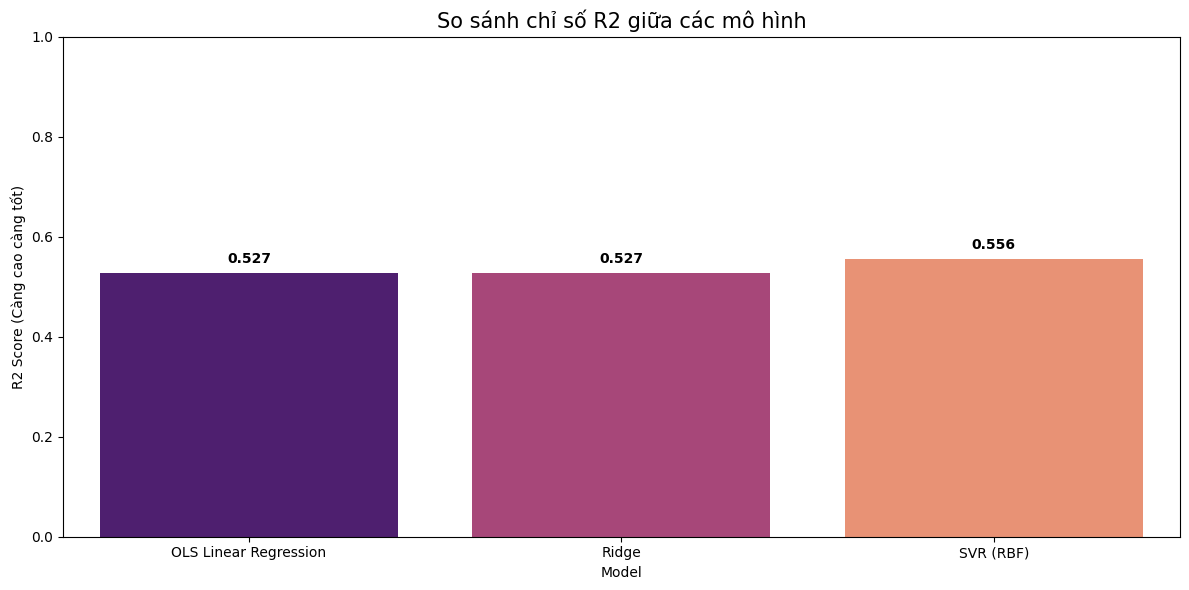

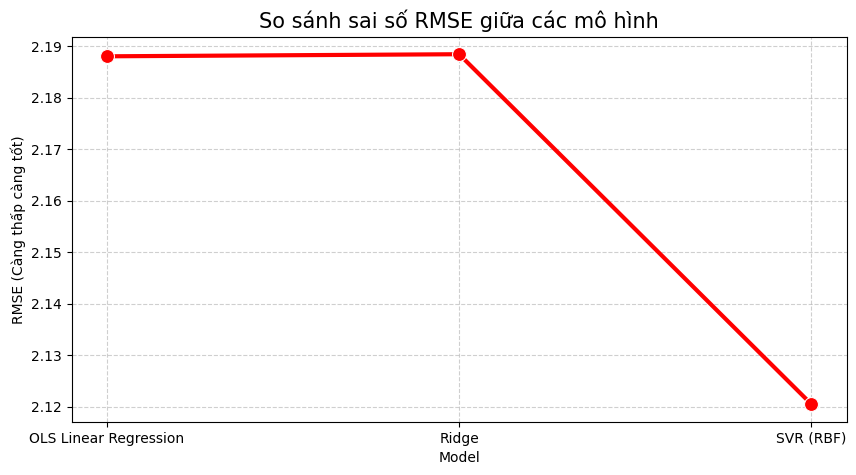

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết kế giao diện biểu đồ
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ cột cho R2 Score
sns.barplot(x='Model', y='R2', data=df_res, palette='magma')
plt.title('So sánh chỉ số R2 giữa các mô hình', fontsize=15)
plt.ylabel('R2 Score (Càng cao càng tốt)')
plt.ylim(0, 1) # Giới hạn trục y từ 0 đến 1
for i, v in enumerate(df_res['R2']):
    plt.text(i, v + 0.02, round(v, 3), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Biểu đồ so sánh RMSE (Sai số)
plt.figure(figsize=(10, 5))
sns.lineplot(x='Model', y='RMSE', data=df_res, marker='o', markersize=10, color='red', linewidth=3)
plt.title('So sánh sai số RMSE giữa các mô hình', fontsize=15)
plt.ylabel('RMSE (Càng thấp càng tốt)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# =========================
# 8. GRID SEARCH (TUNING)
# =========================
# 1. Tuning cho Ridge
param_grid_ridge = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
grid_ridge = GridSearchCV(
    Pipeline([('prep', preprocessor), ('model', Ridge())]),
    param_grid_ridge, cv=5, scoring='r2', n_jobs=-1
)
grid_ridge.fit(X_train, y_train)
score_ridge = grid_ridge.best_score_
best_model_ridge = grid_ridge.best_estimator_

# 2. Tuning cho SVR
param_grid_svr = {
    'model__C': [0.1, 1, 10, 100, 1000],
    'model__epsilon': [0.01, 0.1, 0.5, 1],
    'model__kernel': ['rbf'],
    'model__gamma': ['scale', 'auto']
}
grid_svr = GridSearchCV(
    Pipeline([('prep', preprocessor), ('model', SVR())]),
    param_grid_svr, cv=5, scoring='r2', n_jobs=-1
)
grid_svr.fit(X_train, y_train)
score_svr = grid_svr.best_score_
best_model_svr = grid_svr.best_estimator_

print(f"Best Ridge R2: {score_ridge}")
print(f"Best SVR R2: {score_svr}")

Best Ridge R2: 0.5335597369993103
Best SVR R2: 0.5632831471064174


In [ ]:
#OLS
#huấn luyện OLS Linear Regression (vì nó không cần Tuning)
ols_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])
ols_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Length', 'Diameter',
                                                   'Height', 'Whole_weight',
                                                   'Shucked_weight',
                                                   'Viscera_weight',
                                                   'Shell_weight',
                                                   'Size_Area']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Sex'])])),
                ('model', LinearRegression())])

In [ ]:
_# =========================
# 9. EVALUATE ON TEST SET
# =========================
models_best = {
    "OLS Linear Regression": ols_pipeline, # Model cơ bản
    "Ridge (Tuned)": best_model_ridge,      # Model đã tune alpha
    "SVR (Tuned)": best_model_svr
    }

final_results = []

for name, model in models_best.items():
    y_pred_test = model.predict(X_test)

    final_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred_test),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "R2": r2_score(y_test, y_pred_test)
    })

df_final = pd.DataFrame(final_results)
print("\n--- FINAL COMPARISON ---")
print(df_final)

best_model_name = df_final.loc[df_final['RMSE'].idxmin(), 'Model']
print("\nBest Model:", best_model_name)

best_model = models_best[best_model_name]


--- FINAL COMPARISON ---
                   Model       MAE      RMSE        R2
0  OLS Linear Regression  1.566608  2.181804  0.582822
1          Ridge (Tuned)  1.566629  2.181845  0.582806
2            SVR (Tuned)  1.510797  2.195423  0.577598

Best Model: OLS Linear Regression


lưu model

In [ ]:
import joblib

# Lưu model vào một file có tên là 'abalone_model.pkl'
# Lưu ý: File này sẽ bao gồm cả bộ tiền xử lý (Scaler, Encoder) và Model nhờ vào Pipeline
joblib.dump(best_model, 'abalone_model.pkl')

print("Đã lưu model thành công!")

Đã lưu model thành công!


import model

In [ ]:
import joblib
model = joblib.load('abalone_model.pkl')
print("Model đã sẵn sàng để dự đoán")

Model đã sẵn sàng để dự đoán


VISUALIZATION

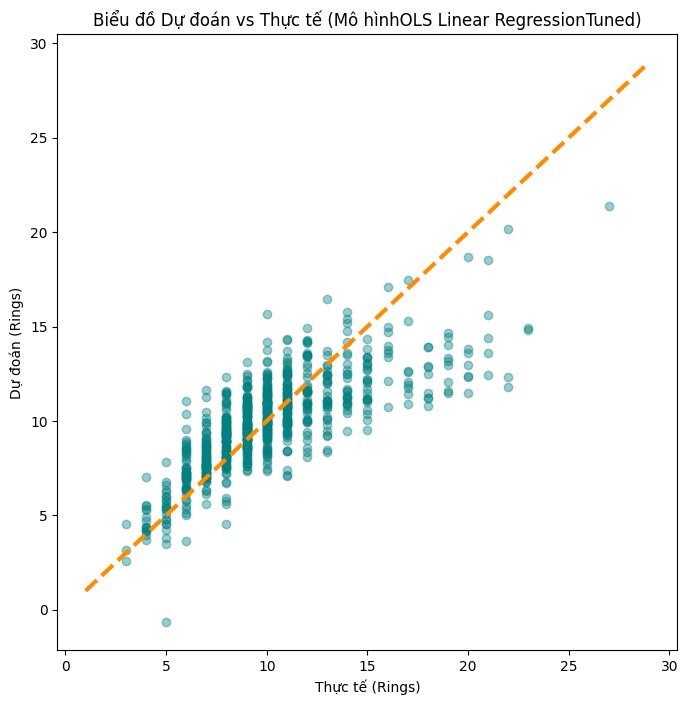

In [ ]:
#PREDICT VS ACTUAL
y_pred_test = best_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.4, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='darkorange', lw=3, linestyle='--')
plt.xlabel('Thực tế (Rings)')
plt.ylabel('Dự đoán (Rings)')
plt.title('Biểu đồ Dự đoán vs Thực tế (Mô hình'+ best_model_name + 'Tuned)')
plt.show()


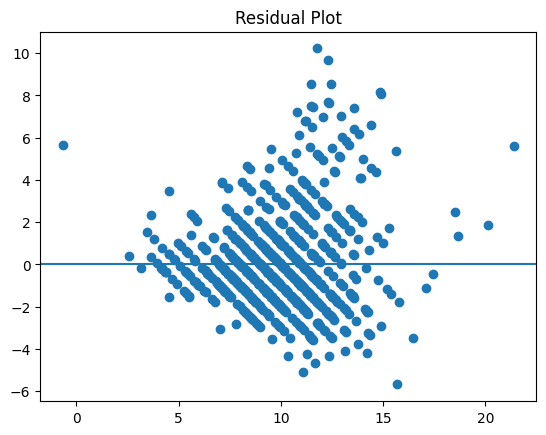

In [ ]:
#RESIDUAL PLOT
residuals = y_test - y_pred_test
plt.figure()
plt.scatter(y_pred_test, residuals)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.show()

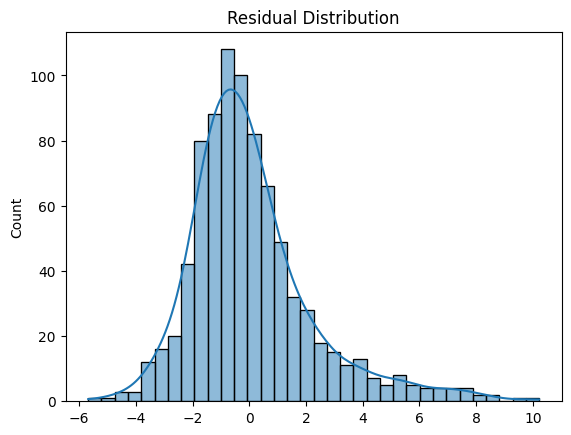

In [ ]:
#RESIDUAL DISTRIBUTION
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

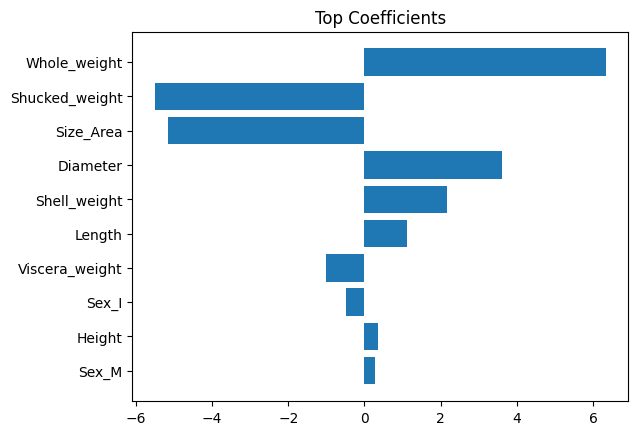

In [ ]:
#COEFFICIENT PLOT
coef = best_model.named_steps['model'].coef_

feature_names = num_cols + list(
    best_model.named_steps['prep']
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols)
)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coef": coef
}).sort_values(by="Coef", key=abs, ascending=False)

plt.figure()
plt.barh(coef_df['Feature'][:10], coef_df['Coef'][:10])
plt.gca().invert_yaxis()
plt.title("Top Coefficients")
plt.show()

ERROR ANALYSIS

Sex
F    1.897879
I    1.097678
M    1.704162
Name: Error, dtype: float64


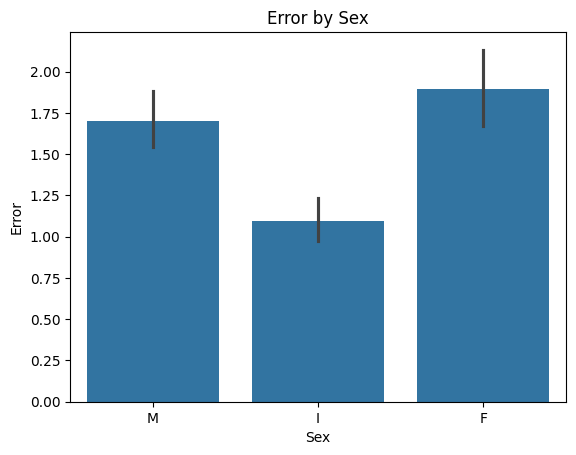

/tmp/ipykernel_343/1195132106.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_test.groupby('Rings_bin')['Error'].mean())


Rings_bin
(0, 5]      0.964906
(5, 10]     1.200894
(10, 15]    1.622970
(15, 20]    4.864263
(20, 30]    6.734199
Name: Error, dtype: float64


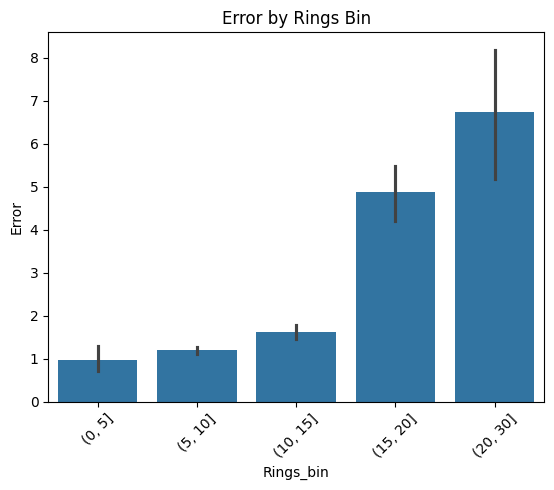

In [ ]:
df_test = X_test.copy()
df_test['True'] = y_test
df_test['Pred'] = y_pred_test
df_test['Error'] = abs(df_test['True'] - df_test['Pred'])
print(df_test.groupby('Sex')['Error'].mean())
#ERROR THEO SEX
sns.barplot(data=df_test, x='Sex', y='Error')
plt.title("Error by Sex")
plt.show()
df_test['Rings_bin'] = pd.cut(df_test['True'], bins=[0,5,10,15,20,30])
#ERROR THEO RINGS BIN
print(df_test.groupby('Rings_bin')['Error'].mean())

sns.barplot(data=df_test, x='Rings_bin', y='Error')
plt.xticks(rotation=45)
plt.title("Error by Rings Bin")
plt.show()

APPLICATION FOR DEMO

In [ ]:
def predict_abalone(model):
    print("=== ENTER ABALONE DATA ===")

    sex = input("Sex (M/F/I): ")
    length = float(input("Length: "))
    diameter = float(input("Diameter: "))
    height = float(input("Height: "))
    whole_weight = float(input("Whole_weight: "))
    shucked_weight = float(input("Shucked_weight: "))
    viscera_weight = float(input("Viscera_weight: "))
    shell_weight = float(input("Shell_weight: "))

    size_area = length * diameter

    data = pd.DataFrame([{
        'Sex': sex,
        'Length': length,
        'Diameter': diameter,
        'Height': height,
        'Whole_weight': whole_weight,
        'Shucked_weight': shucked_weight,
        'Viscera_weight': viscera_weight,
        'Shell_weight': shell_weight,
        'Size_Area': size_area
    }])

    pred = model.predict(data)[0]
    age_pred = pred + 1.5

    print(f"\n Predicted Rings: {np.round(pred).astype(int)}")
    print(f"\n Predicted Age: {np.round(age_pred).astype(int)}")

    return data

In [ ]:
def explain_ridge(model, input_data):
    print("\n Feature Contribution (best_model_name)")

    # Transform input
    transformed = model.named_steps['prep'].transform(input_data)

    # Lấy coef
    coef = model.named_steps['model'].coef_

    # Lấy tên feature
    feature_names = num_cols + list(
        model.named_steps['prep']
        .named_transformers_['cat']
        .get_feature_names_out(cat_cols)
    )

    # Tính contribution
    contributions = transformed[0] * coef

    df_explain = pd.DataFrame({
        "Feature": feature_names,
        "Contribution": contributions
    }).sort_values(by="Contribution", key=abs, ascending=False)

    print(df_explain.head(8))

In [ ]:
# predict
input_data = predict_abalone(best_model)

# explain
explain_ridge(best_model, input_data)

=== ENTER ABALONE DATA ===


In [ ]:
def check_ood(input_data):
    for col in num_cols:
        if input_data[col].values[0] < df[col].min() or input_data[col].values[0] > df[col].max():
            print(f" {col} out of distribution")

In [ ]:
check_ood(input_data)

ACCURACY

In [ ]:
y_pred_test = best_model.predict(X_test)

acc_1 = np.mean(np.abs(y_test - y_pred_test) <= 1)
acc_2 = np.mean(np.abs(y_test - y_pred_test) <= 2)
acc_3 = np.mean(np.abs(y_test - y_pred_test) <= 3)
print("Accuracy (±1 ring):", acc_1)
print("Accuracy (±2 rings):", acc_2)
print("Accuracy (±2 rings):", acc_3)

Accuracy (±1 ring): 0.444311377245509
Accuracy (±2 rings): 0.7437125748502994
Accuracy (±2 rings): 0.8754491017964072
